<a href="https://colab.research.google.com/github/aditi1295/MachineLearning/blob/main/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


1.Preprocessing

In [ ]:
df=df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


EDA

In [ ]:
import matplotlib.pyplot as plt


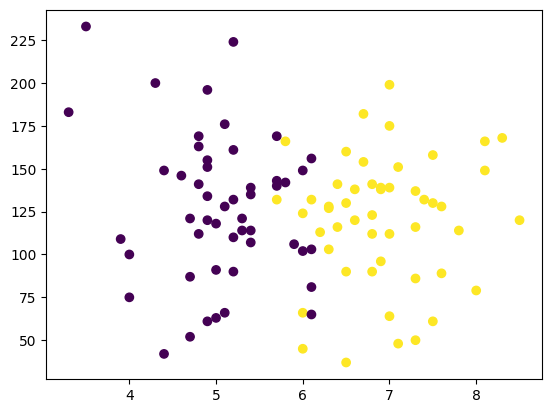

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

2.Extract input and output columns

In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

TRain TEst and Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.1)

In [ ]:
X_train

,cgpa,iq
94,4.7,52.0
87,5.7,132.0
30,7.6,128.0
4,5.8,142.0
92,5.2,110.0
...,...,...
48,6.6,138.0
96,4.4,42.0
35,6.8,90.0
49,5.4,135.0


In [ ]:
Y_train

,placement
94,0
87,1
30,1
4,0
92,0
...,...
48,1
96,0
35,1
49,0


Strandardization

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()

In [ ]:
X_train=scaler.fit_transform(X_train)

In [ ]:
X_train

array([[-1.12011683, -1.77525922],
       [-0.2614242 ,  0.23541663],
       [ 1.37009179,  0.13488284],
       [-0.17555494,  0.48675111],
       [-0.69077051, -0.31751923],
       [-0.69077051, -0.82018819],
       [ 0.59726843,  1.49208904],
       [-0.51903199,  0.41135077],
       [-1.03424757, -0.26725233],
       [-0.00381641, -1.42339094],
       [ 1.97117663,  1.14022076],
       [ 0.85487622,  1.3161549 ],
       [-0.86250904, -1.49879129],
       [-2.15054798,  2.77389489],
       [ 0.76900695,  0.41135077],
       [-0.00381641,  0.03434905],
       [ 1.19835327,  0.23541663],
       [ 0.68313769, -0.26725233],
       [ 1.79943811,  1.08995387],
       [ 1.28422253, -1.54905818],
       [ 1.11248401,  0.36108387],
       [-0.2614242 ,  0.51188456],
       [ 0.76900695,  0.38621732],
       [-0.77663978, -1.42339094],
       [-0.86250904, -0.79505474],
       [-1.03424757,  0.46161766],
       [ 0.85487622, -0.26725233],
       [ 0.08205285, -1.04638922],
       [-1.03424757,

In [ ]:
X_test=scaler.transform(X_test)

In [ ]:
X_test

array([[ 0.08205285, -1.44852439],
       [-0.69077051,  2.54769386],
       [-0.69077051,  0.23541663],
       [ 0.25379138, -0.49345336],
       [ 1.28422253,  0.18514973],
       [-0.60490125, -0.0410513 ],
       [ 0.4255299 ,  0.18514973],
       [ 0.68313769,  0.46161766],
       [-0.9483783 ,  0.81348594],
       [-0.9483783 , -0.06618475]])

Train Model

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf=LogisticRegression()

In [ ]:
clf.fit(X_train,Y_train)

LogisticRegression()

Evaluate the model



In [ ]:
y_pred =clf.predict(X_test)

In [ ]:
Y_test

,placement
56,0
16,0
19,0
98,1
83,1
2,0
57,1
43,1
76,0
22,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(Y_test,y_pred)

0.9

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

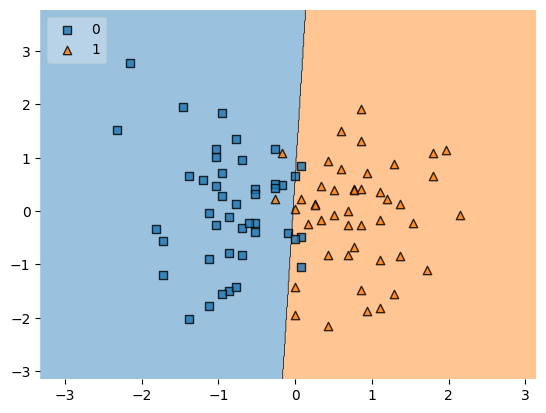

In [ ]:
plot_decision_regions(X_train,Y_train.values, clf=clf ,legend=2)

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))